<span style="float: left;padding: 1.3em">![logo](https://github.com/gw-odw/odw/blob/main/Tutorials/logo.png?raw=1)</span>

# Gravitational Wave Open Data Workshop

## Tutorial 1.2: Accessing Open Data with GWpy & PyCBC

This tutorial will describe how to access open data with GWpy and PyCBC.

View this tutorial on [Google Colaboratory](https://colab.research.google.com/github/gw-odw/odw/blob/main/Tutorials/01_Accessing_Open_Data/Tuto_1.2_Accessing_Open_Data_with_GWpy_PyCBC.ipynb) or launch [mybinder](https://mybinder.org/v2/gh/gw-odw/odw/HEAD).


In [1]:
# Those 2 lines are just to avoid some harmless warnings when importing packages
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

## Installation (execute only if running on a cloud platform, like Google Colab, or if you haven't done the installation already!)

> ⚠️ **Warning**: restart the runtime after running the cell below.
>
> To do so, click "Runtime" in the menu and choose "Restart and run all".
>
> You may see error messages but installation usually works.
> If you experience problems, please [report an issue](https://github.com/gw-odw/odw/issues).

In [2]:
# -- Uncomment following line if running in Google Colab
! pip install -q 'gwpy==3.0.14' 'PyCBC==2.10.0' 'cryptography==43.0.0'

## Introduction

We have seen already that the `gwosc` module can be used to query for what data are available on [GWOSC](https://gwosc.org/data/).
The next thing to do is to actually read some open data.

We will present 2 packages to do this:
- [GWpy](https://gwpy.readthedocs.io/en/v3.0.14/), a python package for gravitational astrophysics.
- [PyCBC](https://pycbc.org/), a software package used to explore astrophysical sources of gravitational waves.

We will use them in the following tutorials but we can't present them in depth.
In case of problem, refer to the documentation.

In [3]:
# The first import of gwpy can take some time (especially on cloud platforms).
# This is mainly due to matplotlib taking some time to import (this is normal).
import gwpy
print("GWpy version: ", gwpy.__version__)
import pycbc
print("PyCBC version:", pycbc.__version__)

GWpy version:  3.0.14
PyCBC version: 2.10.0


## Open Data Access with GWpy

### A note on object-oriented programming

Before we dive too deeply, it's worth a quick aside on object-oriented programming (OOP).
[GWpy](https://gwpy.readthedocs.io/en/v3.0.14/index.html) is heavily object-oriented, meaning almost all of the code you run using GWpy is based around an object of some type, e.g. [`TimeSeries`](https://gwpy.readthedocs.io/en/v3.0.14/api/gwpy.timeseries.TimeSeries/#gwpy.timeseries.TimeSeries).
Most of the methods (functions) we will use are attached to an object, rather than standing alone, meaning you should have a pretty good idea of what sort of data you are dealing with (without having to read the documentation!).

For a quick overview of object-oriented programming in Python, see [this blog post by Jeff Knupp](https://medium.com/hackernoon/improve-your-python-python-classes-and-object-oriented-programming-d09ff461168d).

### Finding open data

Let's try to get some for GW190412, the first detection of a gravitational-wave signal from a significantly unequal-mass BBH (binary black hole system).

We can use the [TimeSeries.fetch_open_data](https://gwpy.readthedocs.io/en/v3.0.14/api/gwpy.timeseries.TimeSeries/#gwpy.timeseries.TimeSeries.fetch_open_data) method to download data directly from https://gwosc.org, but we need to know the GPS times.
We can query for the GPS time of an event as follows:

In [4]:
from gwosc.datasets import event_gps
gps = event_gps('GW190412')
print(gps)

1239082262.1


Now we can build a `[start, end)` GPS segment to 10 seconds around this time, using integers for convenience:

In [5]:
start, stop = segment = (int(gps)-5, int(gps)+5)
print(segment)

(1239082257, 1239082267)


We can now query for the full data.
For this example we choose to retrieve data for the LIGO-Livingston interferometer, using the identifier `'L1'`.

In [6]:
from gwpy.timeseries import TimeSeries
ldata = TimeSeries.fetch_open_data('V1', *segment, verbose=True)
print(ldata)

Fetched 1 URLs from gwosc.org for [1239082257 .. 1239082267))
Reading data... [Done]
TimeSeries([-4.14628280e-20, -2.16068322e-20,  8.49382876e-21,
            ...,  1.97669207e-20, -7.11263366e-21,
            -2.44333694e-20]
           unit: dimensionless,
           t0: 1239082257.0 s,
           dt: 0.000244140625 s,
           name: Strain,
           channel: None)


##### The `verbose=True` flag lets us see that GWpy has discovered one file that provides the data for the given interval, downloaded it, and loaded the data.
The files are not stored permanently, so next time you do the same call, it will be downloaded again, however, if you know you might repeat the same call many times, you can use `cache=True` to store the file on your computer.

Notes:

* To control the dataset from which your data come from you can use the 'dataset' keyword. It is recommended to use data from a run if they are available, because they contain the most updated version of the calibration. To check which was the run at the time you want to query, it is enough to use the find_datasets method of the package gwosc discussed in the previous tutorial, specifying (`type='run',segment=segment`). For example, for the segment we are using in this tutorial, the two available datasets are [`'O3a_16KHZ_R1'`, `'O3a_4KHZ_R1'`]. For the sampling at 4 kHz, the complete command to get data from this dataset is then: `TimeSeries.fetch_open_data('L1', *segment, verbose=True, dataset='O3a_4KHZ_R1')`.  

* To read data from a local file instead of from the GWOSC server, we can use  [`TimeSeries.read`](https://gwpy.readthedocs.io/en/v3.0.14/api/gwpy.timeseries.TimeSeries/#gwpy.timeseries.TimeSeries.read) method.

We have now downloaded real LIGO data for GW190412! These are the actual data used in the analysis of this binary black hole merger.

To sanity check things, we can easily make a plot, using the [`plot()`](https://gwpy.readthedocs.io/en/v3.0.14/plot/) method of the `data` `TimeSeries`.

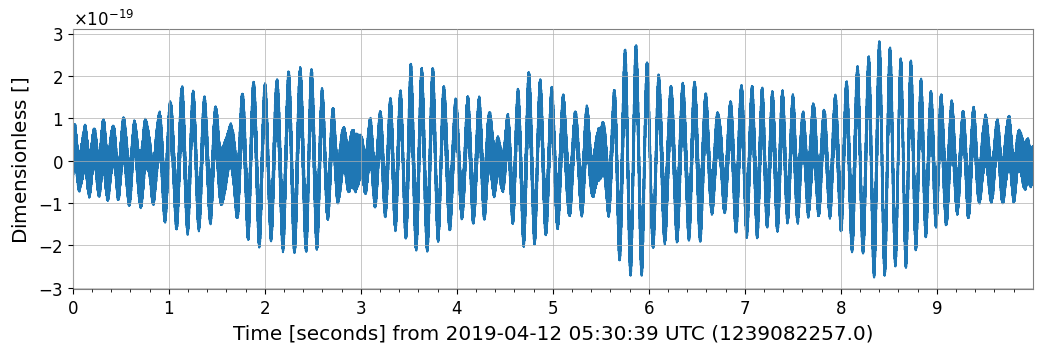

In [7]:
plot = ldata.plot()

## Open Data Access with PyCBC

PyCBC also proposes an object-oriented interface.
In particular, it also offers a [`TimeSeries`](https://pycbc.org/pycbc/latest/html/pycbc.types.html#pycbc.types.timeseries.TimeSeries) class that is similar but different than the one in GWpy.

### Finding open data

Similarly, let's try to get some for GW190412.

We can use the [read_strain_gwosc](https://pycbc.org/pycbc/latest/html/pycbc.frame.html#pycbc.frame.gwosc.read_strain_gwosc) method to download data directly from https://gwosc.org.
As before, we need to know the GPS times so we will reuse them.

In [8]:
from pycbc.frame.gwosc import read_strain_gwosc

ldata = read_strain_gwosc('L1', *segment)

The files are not stored permanently, so next time you do the same call, it will be downloaded again.
Also, this method downloads data sampled at 16kHz so this takes longer and uses more memory.
It might be mode efficient to download the data with `GWpy` and convert with `to_pycbc()`.

Notes:

* To read data from a local file instead of from the GWOSC server, we can use  [`read_frame`](https://pycbc.org/pycbc/latest/html/pycbc.frame.html#pycbc.frame.frame.read_frame) method.

We have now downloaded real LIGO data for GW190412! These are the actual data used in the analysis of this binary black hole merger.

To sanity check things, we can easily make a plot, using the [`plot()`](https://gwpy.readthedocs.io/en/v3.0.14/api/gwpy.timeseries.TimeSeries/#gwpy.timeseries.TimeSeries.plot) method of the `TimeSeries` class.
See also [this tutorial](https://gwpy.readthedocs.io/en/v3.0.14/plot/).

Text(0, 0.5, 'Strain (dimensionless)')

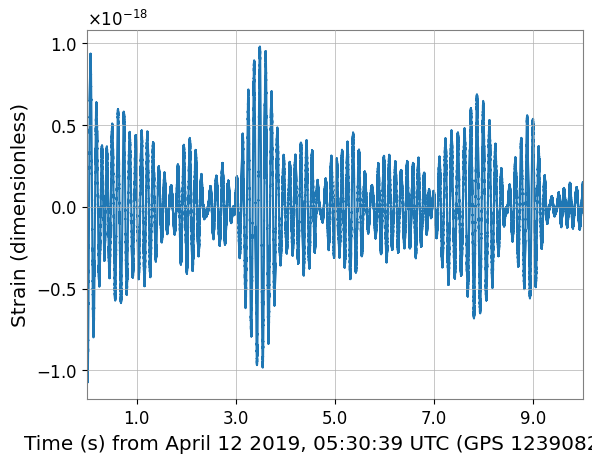

In [9]:
from lal.gpstime import gps_to_str

line = ldata.plot()
#all this stuff under is not really needed
figure = line[0].figure
axis = figure.gca()
ticks = axis.get_xticks()
axis.set_xticks(ticks, labels=(ticks - start))
axis.set_xlim(start, stop)
axis.set_xlabel("Time (s) from {0} (GPS {1})".format(gps_to_str(start), start))
axis.set_ylabel("Strain (dimensionless)")

PyCBC contains an interface to the [GWOSC catalog](https://gwosc.org/eventapi/), so you can easily access the data and parameters of the published gravitational-wave signals.
For instance to download strain data you can use the [strain](https://pycbc.org/pycbc/latest/html/pycbc.catalog.html#pycbc.catalog.Merger.strain) method of the [Merger](https://pycbc.org/pycbc/latest/html/pycbc.catalog.html#pycbc.catalog.Merger) class.
This will download the 32s segments around the event.

Text(0, 0.5, 'Strain (dimensionless)')

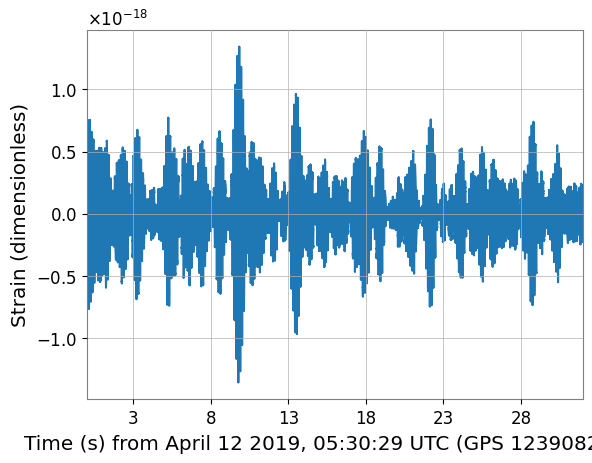

In [10]:
from pycbc.catalog import Merger

GW190412 = Merger('GW190412')
segment = GW190412.strain('L1')
line = segment.plot()
figure = line[0].figure
axis = figure.gca()
ticks = axis.get_xticks()
axis.set_xticks(ticks, labels=(ticks - segment.start_time))
axis.set_xlim(segment.start_time.gpsSeconds, segment.end_time.gpsSeconds)
axis.set_xlabel("Time (s) from {0} (GPS {1})".format(gps_to_str(segment.start_time), segment.start_time))
axis.set_ylabel("Strain (dimensionless)")

## Quiz Questions

Please try and complete the following exercises using that interface and enter you response on Thinkific.

### Question 1

Looking at the LIGO-Livingston data in the time domain, the peak amplitude of the gravitational-wave signal of GW190412  occurs at the center of the figure, that is, at approximately 5 seconds from the start of the segment. This peak is undetectable above the background noise by the eye. Plot the data for the LIGO-Hanford and Virgo detectors around GW190412. Looking at your new plots, can your eye identify a signal peak? You can use GWpy or PyCBC.